In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from pyomo.environ import *
from param_loader import METANET_Params
from simulation_utils import *
from mpc_utils import *
from eval_metrics import *
from optimization_utils import *
import os
import logging

In [23]:
# I-5
# q_hat = np.load("I5_400m_10s_16segments/flow_matrix_asm.npy")[0:350,:]
# rho_hat = np.load("I5_400m_10s_16segments/density_matrix_asm.npy")[0:350,:]

# lanes_per_bin = np.load("I5_400m_10s_16segments/lanes_per_bin.npy")
# lane_mapping = {i: float(lanes_per_bin[i]) for i in range(len(lanes_per_bin))}
#I-24
q_hat = np.load("data/flow_10sec_400m_1hr.npy")#[0:270, :]
rho_hat = np.load("data/density_10sec_400m_1hr.npy")#[0:270, :]

v_hat = q_hat / rho_hat
print(rho_hat.shape)

rho_hat = np.where(rho_hat == 0.0, 1e-3, rho_hat)
q_hat = np.where(q_hat == 0.0, 1e-3, q_hat)

random.seed(1)
np.random.seed(1)


(360, 16)


In [65]:
T = 10 / 3600
l = 0.4
num_calibrated_segments = rho_hat.shape[1] - 2
include_ramping = True
varylanes = False
control_h = 10

In [66]:
logging.getLogger('pyomo.core').setLevel(logging.ERROR)

robust_opt_params = RobustOptConfig(S=10, bc_noise_percent=0.0001, seed=2, objective_mode="mean")

calibrate_params_mpc(
    rho_hat,
    q_hat,
    T,
    l,
    control_h,
    pred_h = 30,
    # lane_mapping=lane_mapping,
    num_calibrated_segments=num_calibrated_segments,
    include_ramping=include_ramping,
    varylanes=varylanes,
    smoothing=True,
    constraint_tol=1e-9,
    verbose=True,
    results_root_dir="robust_mpc_calibration_results/S10_warmstart_widebounds",
    robust_opt=robust_opt_params,
    enforce_ramps=False,
    warmstart="use_standard_mpc"
)



Using warmstart from: mpc_calibration_results/control_h_10/params_1
Number of robust scenarios S = 10 with bc noise percent = 0.0001
Ipopt 3.14.16: max_iter=20000
acceptable_constr_viol_tol=1e-09
constr_viol_tol=1e-09
warm_start_init_point=yes
mu_init=0.001


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    72200
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    68060

Total number of variables............................:     8512
                     vari

In [67]:
num_lanes_array = np.array([4 for i in range(num_calibrated_segments)])

scaled_rho_hat = rho_hat[:, 1:-1] / np.array(num_lanes_array)
downstream_density = smooth_inflow(rho_hat[:, -1] / num_lanes_array[-1])
data_inflow = smooth_inflow(q_hat[:, 0])
init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)

v_pred , v_sim = simulate_multiple_params(
    init_traffic_state,
    downstream_density,
    data_inflow,
    T,
    l,
    10, #control_h,
    root_results_dir="robust_mpc_calibration_results/S10_warmstart_widebounds",)

print(f"MPC with control horizon {control_h} --- Simulation MAPE: {mape(v_hat[:, 1:-1], v_sim[:, :])}")

MPC with control horizon 10 --- Simulation MAPE: 9.214541610178095


Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 102.5494591064967


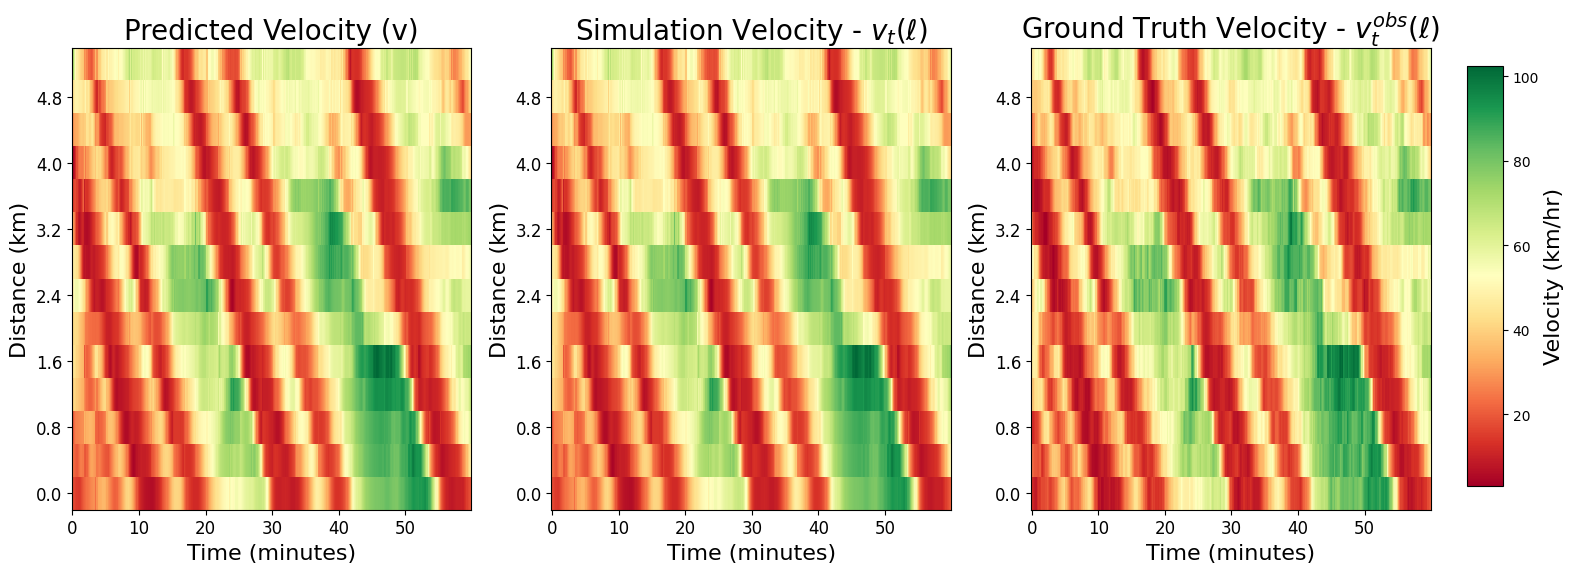

In [68]:
v_plot_true = v_hat[:, 1:-1]


print("Pred shape:", v_pred.shape)
print("True shape:", v_plot_true.shape)
print("Max true density:", np.max(v_plot_true))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Compute common color scale ---
vmin = min(
    np.min(v_pred),
    np.min(v_sim),
    np.min(v_plot_true),
)
vmax = max(
    np.max(v_pred),
    np.max(v_sim),
    np.max(v_plot_true),
)

# vmin = 0
# vmax = 150
# --- Prediction ---
im0 = axes[0].imshow(
    v_pred.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Segment Index")
axes[0].set_title("Predicted Velocity (v)")

# --- Simulation ---
im1 = axes[1].imshow(
    v_sim.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_xlabel("Time Step")
axes[1].set_title("Simulation Velocity - $v_t(\\ell)$", fontsize=20)

# --- Ground Truth ---
im2 = axes[2].imshow(
    v_plot_true.T,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn",
    interpolation="none",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_xlabel("Time Step")
axes[2].set_title(
    "Ground Truth Velocity - $v^{obs}_t(\\ell)$",
    fontsize=20,
)

# ---- One shared colorbar in its own axis ----
# Make room on the right for the colorbar
fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im0, cax=cbar_ax)
cbar.set_label("Velocity (km/hr)", fontsize=16)

# Convert x label to minutes
for ax in axes:
    ax.set_xlabel("Time (minutes)")

# Convert x ticks to minutes
num_time_steps = v_pred.shape[0]
time_step_indices = np.arange(0, num_time_steps, max(1, num_time_steps // 6))
time_step_labels = [f"{(i * T * 60):.0f}" for i in time_step_indices]
for ax in axes:
    ax.set_xticks(time_step_indices)
    ax.set_xticklabels(time_step_labels)

# Convert y axis to kilometers
for ax in axes:
    num_segments = v_pred.shape[1]
    segment_indices = np.arange(0, num_segments, max(1, num_segments // 6))
    segment_labels = [f"{(i * l):.1f}" for i in segment_indices]
    ax.set_yticks(segment_indices)
    ax.set_yticklabels(segment_labels)
    ax.set_ylabel("Distance (km)")

# label font size
for ax in axes:
    ax.title.set_fontsize(20)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis='both', which='major', labelsize=12)    

plt.show()




In [69]:
epsilons = [1e-13, 1e-7, 1e-4, 0.01, 0.1, 1, 5]
eval_results = eval_robustness_dynamic(v_hat[:, 1:-1], 10, "robust_mpc_calibration_results/S10_warmstart_widebounds", data_inflow, downstream_density, 
                                            init_traffic_state, T=T, l=l, percent_noises=epsilons, save_results=True)
    

/Users/shreyaar/Desktop/macroscopic-sim-calibration/simulation_utils.py:33: RuntimeWarning: invalid value encountered in scalar power
  return v_free * np.exp(- (rho / p_crit) ** a / a)


Robustness error with 1e-13% noise level on inflows: worst-case = 11.39598646026219 / mean = 10.382568711818525


/Users/shreyaar/Desktop/macroscopic-sim-calibration/simulation_utils.py:33: RuntimeWarning: invalid value encountered in scalar power
  return v_free * np.exp(- (rho / p_crit) ** a / a)


Robustness error with 1e-07% noise level on inflows: worst-case = 46.20694432619426 / mean = 30.236735947346684


/Users/shreyaar/Desktop/macroscopic-sim-calibration/simulation_utils.py:33: RuntimeWarning: invalid value encountered in scalar power
  return v_free * np.exp(- (rho / p_crit) ** a / a)


...

Robustness error with 0.1% noise level on inflows: worst-case = 105.29620740856834 / mean = 64.47661827851907


/Users/shreyaar/Desktop/macroscopic-sim-calibration/simulation_utils.py:33: RuntimeWarning: invalid value encountered in scalar power
  return v_free * np.exp(- (rho / p_crit) ** a / a)


Robustness error with 1% noise level on inflows: worst-case = 104.1721276469195 / mean = 79.78993703356146


/Users/shreyaar/Desktop/macroscopic-sim-calibration/simulation_utils.py:33: RuntimeWarning: invalid value encountered in scalar power
  return v_free * np.exp(- (rho / p_crit) ** a / a)


Robustness error with 5% noise level on inflows: worst-case = 110.1768170174191 / mean = 83.15297436886092
Results saved to robust_mpc_calibration_results/S10_warmstart_widebounds/control_h_10/noise_robustness_results.csv


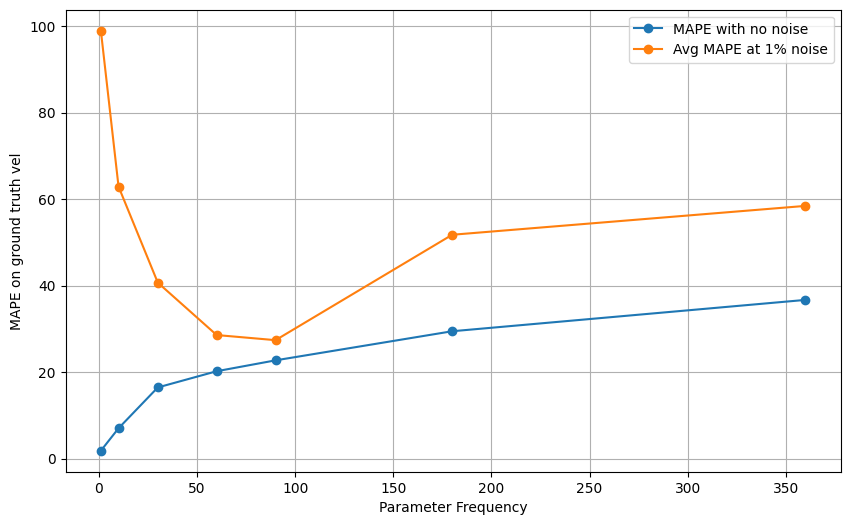

In [6]:
plot_mpc_acc_robustness("mpc_calibration_results", [1, 10, 30, 60, 90, 180, 360], percent_noise=1)

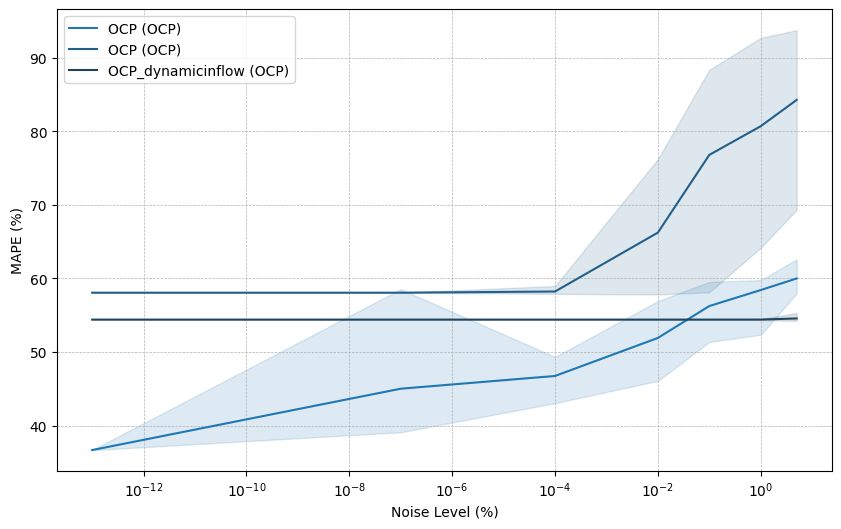

In [74]:
dir_to_plot = ["calibration_results/OCP",
               "itsc_final/calibration_results/OCP",
               "itsc_final/calibration_results/OCP_dynamicinflow"]
            #    "robust_mpc_calibration_results/S5/control_h_10",
            #    "mpc_calibration_results/control_h_10",
            #    "mpc_calibration_results/control_h_30",
            #    "mpc_calibration_results/control_h_60",
            #    "mpc_calibration_results/control_h_90"]

plot_percentile_curves(dir_to_plot)

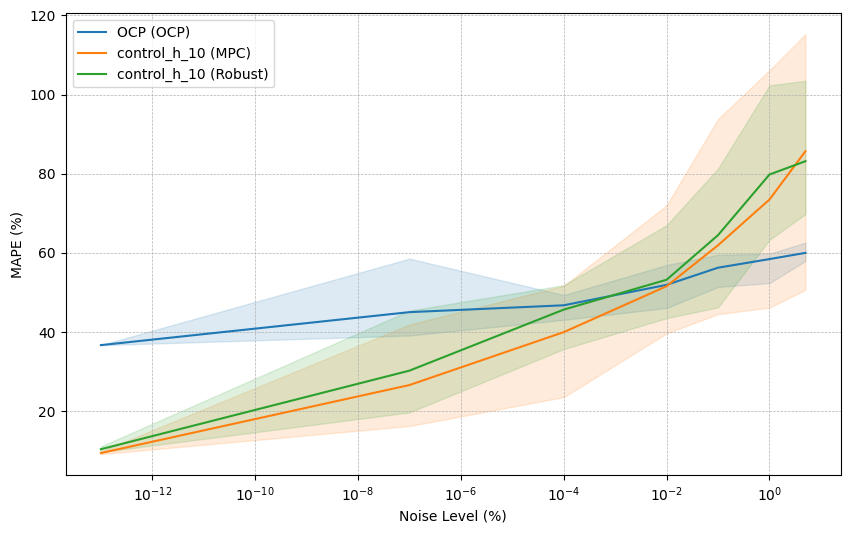

In [70]:
plot_percentile_curves([#"robust_mpc_calibration_results/baseline2_warmstart/control_h_30",
                        # "robust_mpc_calibration_results/baseline_mpc/control_h_30",
                        "calibration_results/OCP",
                        "mpc_calibration_results/control_h_10",
                        "robust_mpc_calibration_results/S10_warmstart_widebounds/control_h_10",
                        #"robust_mpc_calibration_results/S5_max/control_h_30"
                        ])